In [ ]:
import subprocess, sys
def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip("nadirclaw", "openai", "sentence-transformers", "matplotlib",
     "scikit-learn", "pandas", "requests")

import os, json, time, signal, shutil, getpass
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "").strip()
if not GEMINI_API_KEY:
    print("Paste your Gemini API key (input hidden), or press Enter to skip:")
    try:
        GEMINI_API_KEY = getpass.getpass(prompt="GEMINI_API_KEY: ").strip()
    except (EOFError, KeyboardInterrupt):
        GEMINI_API_KEY = ""

LIVE_ROUTING = bool(GEMINI_API_KEY)
if LIVE_ROUTING:
    os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY
    print(f"✓ key captured ({len(GEMINI_API_KEY)} chars) — sections 8–11 enabled.")
else:
    print("ℹ no key entered — sections 3–7 still run; live routing skipped.")

In [ ]:
def classify(prompt: str) -> dict:
    r = subprocess.run(
        ["nadirclaw", "classify", "--format", "json", prompt],
        capture_output=True, text=True, timeout=180,
    )
    if r.returncode != 0:
        return {"prompt": prompt, "error": (r.stderr or r.stdout).strip()}
    return json.loads(r.stdout.strip())

prompts = [
    "What is 2+2?",
    "Format this JSON: {\"a\":1,\"b\":2}",
    "Read the file at src/main.py",
    "Add a docstring to the foo function",
    "What does this function do?",
    "Refactor the auth module to use dependency injection without breaking existing callers",
    "Design a distributed event-sourced order pipeline that handles 50k req/s with strict ordering",
    "Analyze the tradeoffs between actor-model and CSP-style concurrency for our codebase",
    "Debug why this asyncio.gather call deadlocks under high load and provide a fix",
    "Prove that this scheduling algorithm is optimal step by step and derive the worst-case bound",
]

print("\n[3] Classifying 10 prompts (first call warms the encoder)…")
rows = [classify(p) for p in prompts]
df = pd.DataFrame(rows)
cols = [c for c in ["tier", "score", "confidence", "model", "prompt"] if c in df.columns]
print(df[cols].to_string(index=False))

import nadirclaw
PKG = Path(nadirclaw.__file__).parent
SIMPLE_C = np.load(PKG / "simple_centroid.npy").astype(np.float32).flatten()
COMPLEX_C = np.load(PKG / "complex_centroid.npy").astype(np.float32).flatten()

def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

print(f"\n[4] simple_centroid  shape={SIMPLE_C.shape}  ‖·‖={np.linalg.norm(SIMPLE_C):.3f}")
print(f"    complex_centroid shape={COMPLEX_C.shape}  ‖·‖={np.linalg.norm(COMPLEX_C):.3f}")
print(f"    cosine(simple,complex) = {cosine(SIMPLE_C, COMPLEX_C):.4f}  "
      "← if this were 1.0 the classifier couldn't distinguish them.")

In [ ]:
from sentence_transformers import SentenceTransformer
print("\n[5] Loading the same encoder NadirClaw uses (all-MiniLM-L6-v2)…")
encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embs = encoder.encode(prompts, normalize_embeddings=True)

sim_simple = np.array([cosine(e, SIMPLE_C) for e in embs])
sim_complex = np.array([cosine(e, COMPLEX_C) for e in embs])

fig, ax = plt.subplots(figsize=(8.5, 6))
colors = ["tab:blue"] * 5 + ["tab:red"] * 5
ax.scatter(sim_simple, sim_complex, c=colors, s=110, edgecolor="k", linewidth=0.5)
for i, _ in enumerate(prompts):
    ax.annotate(str(i + 1), (sim_simple[i], sim_complex[i]),
                xytext=(6, 4), textcoords="offset points", fontsize=10)
xs = np.linspace(min(sim_simple.min(), sim_complex.min()),
                 max(sim_simple.max(), sim_complex.max()), 50)
ax.plot(xs, xs, "k--", alpha=0.4, label="cos(simple) = cos(complex)")
ax.set_xlabel("cosine similarity to SIMPLE centroid")
ax.set_ylabel("cosine similarity to COMPLEX centroid")
ax.set_title("Routing decision boundary\n(blue = expected simple, red = expected complex)")
ax.legend(loc="lower right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("centroid_decision_plot.png", dpi=120)
plt.show()
print("Legend: prompts above the dashed line route to COMPLEX, below to SIMPLE.")

print("\n[6] Prompts sorted by complexity score:")
sdf = df.sort_values("score").reset_index(drop=True)
for _, row in sdf.iterrows():
    bar = "█" * int(round(float(row["score"]) * 30))
    print(f"  score={float(row['score']):.2f}  conf={float(row['confidence']):.2f}  "
          f"{row['tier']:7s} |{bar:<30s}| {row['prompt'][:55]}")

print("\n[6] Confidence-threshold sweep (low confidence → forced complex):")
print("    NadirClaw default threshold is 0.06.")
for thr in [0.02, 0.06, 0.10, 0.20, 0.30]:
    forced_complex = sum(1 for r in rows if float(r["confidence"]) < thr)
    natural_complex = sum(1 for r in rows if float(r["score"]) >= 0.5)
    print(f"    threshold={thr:.2f} → {forced_complex} prompts force-complex "
          f"(low-confidence), {natural_complex} naturally complex by score")

modifier_demos = [
    ("agentic — text-only marker",
     "You are a coding agent that can execute commands. Now add tests for the new endpoint."),
    ("reasoning — chain-of-thought markers",
     "Step by step, derive the closed form and prove correctness mathematically. "
     "Compare and contrast both approaches."),
    ("vision — would arrive with image_url part (only text shown)",
     "Describe the screenshot."),
]
print("\n[7] Modifier-marker scan:")
for label, p in modifier_demos:
    r = classify(p)
    print(f"    {label}")
    print(f"      prompt='{p[:65]}…'")
    print(f"      tier={r['tier']}  score={float(r['score']):.2f}  conf={float(r['confidence']):.2f}")
print("    NB: agentic & vision routing also trigger from request shape "
      "(tools=[…], image_url parts) — see live calls below.")

In [ ]:
PORT = 8856
server_proc = None
if LIVE_ROUTING:
    print(f"\n[8] Starting `nadirclaw serve` on :{PORT} (background subprocess)…")
    env = os.environ.copy()
    env.update({
        "GEMINI_API_KEY": GEMINI_API_KEY,
        "NADIRCLAW_SIMPLE_MODEL": "gemini-2.5-flash",
        "NADIRCLAW_COMPLEX_MODEL": "gemini-2.5-pro",
        "NADIRCLAW_PORT": str(PORT),
    })
    server_proc = subprocess.Popen(
        ["nadirclaw", "serve", "--verbose"],
        env=env,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        preexec_fn=os.setsid if hasattr(os, "setsid") else None,
    )
    ready = False
    for _ in range(60):
        if server_proc.poll() is not None:
            break
        try:
            if requests.get(f"http://localhost:{PORT}/health", timeout=1).ok:
                ready = True
                break
        except Exception:
            time.sleep(1)
    if ready:
        print("    ✓ /health returned 200 — proxy is live.")
    else:
        print("    ⚠ proxy did not come up; dumping last log lines:")
        if server_proc.stdout:
            try:
                lines = server_proc.stdout.read1(4096).decode("utf-8", errors="replace")
                print(lines[-2000:])
            except Exception as e:
                print(f"    (could not read server stdout: {e})")
else:
    print("\n[8] Skipped — no GEMINI_API_KEY.")

def proxy_alive():
    return server_proc is not None and server_proc.poll() is None

if proxy_alive():
    from openai import OpenAI
    client = OpenAI(base_url=f"http://localhost:{PORT}/v1", api_key="local")

    side_by_side = [
        ("simple-ish", "Write a one-line docstring for: def add(a, b): return a + b"),
        ("complex",    "Refactor a Python class to a dependency-injection pattern, "
                       "explain the trade-offs, and produce migration steps for callers."),
    ]
    summary = []
    for label, p in side_by_side:
        t0 = time.time()
        try:
            resp = client.chat.completions.create(
                model="auto",
                messages=[{"role": "user", "content": p}],
                max_tokens=220,
            )
            dt = time.time() - t0
            text = (resp.choices[0].message.content or "").strip()
            print(f"\n--- [{label}] {dt:.2f}s · model={resp.model} ---")
            print(text[:500] + ("…" if len(text) > 500 else ""))
            summary.append({
                "label": label, "model_used": resp.model,
                "latency_s": round(dt, 2),
                "tokens": getattr(resp.usage, "total_tokens", None),
            })
        except Exception as e:
            summary.append({"label": label, "model_used": "ERROR",
                            "latency_s": None, "tokens": str(e)[:80]})
            print(f"⚠ [{label}] failed: {e}")

    print("\n[9] Summary:")
    print(pd.DataFrame(summary).to_string(index=False))

Paste your Gemini API key (input hidden), or press Enter to skip:
GEMINI_API_KEY: ··········
✓ key captured (39 chars) — sections 8–11 enabled.

[3] Classifying 10 prompts (first call warms the encoder)…
   tier  score  confidence                      model                                                                                        prompt
 simple    0.0      0.2848     gemini-3-flash-preview                                                                                  What is 2+2?
 simple    0.0      0.1255     gemini-3-flash-preview                                                               Format this JSON: {"a":1,"b":2}
 simple    0.0      0.3380     gemini-3-flash-preview                                                                  Read the file at src/main.py
 simple    0.0      0.2890     gemini-3-flash-preview                                                           Add a docstring to the foo function
 simple    0.0      0.2840     gemini-3-flash-preview   

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


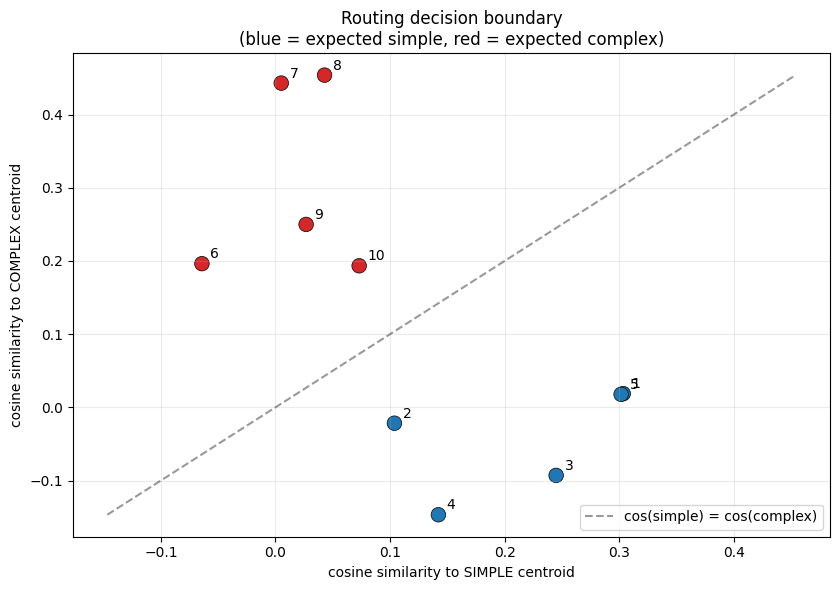

Legend: prompts above the dashed line route to COMPLEX, below to SIMPLE.

[6] Prompts sorted by complexity score:
  score=0.00  conf=0.28  simple  |                              | What is 2+2?
  score=0.00  conf=0.13  simple  |                              | Format this JSON: {"a":1,"b":2}
  score=0.00  conf=0.34  simple  |                              | Read the file at src/main.py
  score=0.00  conf=0.29  simple  |                              | Add a docstring to the foo function
  score=0.00  conf=0.28  simple  |                              | What does this function do?
  score=1.00  conf=0.26  complex |██████████████████████████████| Refactor the auth module to use dependency injection wi
  score=1.00  conf=0.44  complex |██████████████████████████████| Design a distributed event-sourced order pipeline that 
  score=1.00  conf=0.41  complex |██████████████████████████████| Analyze the tradeoffs between actor-model and CSP-style
  score=1.00  conf=0.22  complex |██████████████████

In [1]:
if proxy_alive():
    print("\n[10] Mixed 10-prompt workload…")
    workload = [
        "Capital of France?",
        "Read foo.py",
        "Type hint for a list of dicts",
        "Lowercase: HELLO",
        "One-sentence summary of REST",
        "Refactor a callback chain into async/await with proper error handling",
        "Design a sharded multi-region key-value store with linearizable reads",
        "Analyze the asymptotic complexity of this code and prove the bound rigorously",
        "Debug why our gRPC stream stalls when the client TCP window saturates",
        "Compare and contrast B-trees and LSM-trees for write-heavy workloads",
    ]
    runs = []
    client = OpenAI(base_url=f"http://localhost:{PORT}/v1", api_key="local")
    for p in workload:
        t0 = time.time()
        try:
            r = client.chat.completions.create(
                model="auto",
                messages=[{"role": "user", "content": p}],
                max_tokens=140,
            )
            usage = getattr(r, "usage", None)
            runs.append({
                "prompt": p[:55],
                "model": r.model,
                "latency_s": round(time.time() - t0, 2),
                "in_tok": getattr(usage, "prompt_tokens", 0) if usage else 0,
                "out_tok": getattr(usage, "completion_tokens", 0) if usage else 0,
            })
        except Exception as e:
            runs.append({"prompt": p[:55], "model": "ERROR",
                         "latency_s": None, "in_tok": 0, "out_tok": 0,
                         "error": str(e)[:80]})

    rdf = pd.DataFrame(runs)
    print(rdf.to_string(index=False))

    PRICE = {
        "flash": {"in": 0.30 / 1e6, "out": 2.50 / 1e6},
        "pro":   {"in": 1.25 / 1e6, "out": 10.0 / 1e6},
    }
    def price_for(model_str, in_t, out_t):
        m = (model_str or "").lower()
        tier = "flash" if "flash" in m else "pro"
        return in_t * PRICE[tier]["in"] + out_t * PRICE[tier]["out"]

    cost_routed = sum(price_for(r["model"], r["in_tok"], r["out_tok"]) for r in runs)
    cost_no_route = sum(price_for("gemini-2.5-pro", r["in_tok"], r["out_tok"]) for r in runs)

    print(f"\n[10] Cost (NadirClaw routed)        : ${cost_routed:.6f}")
    print(f"     Cost (always-Pro baseline)     : ${cost_no_route:.6f}")
    if cost_no_route > 0:
        print(f"     Estimated savings on this run  : "
              f"{(1 - cost_routed/cost_no_route) * 100:.1f}%")

print("\n[11] `nadirclaw report` (parses the JSONL request log):")
rep = subprocess.run(["nadirclaw", "report"], capture_output=True, text=True, timeout=60)
print(rep.stdout or rep.stderr)

if proxy_alive():
    print("\n[12] Stopping the proxy…")
    try:
        if hasattr(os, "killpg"):
            os.killpg(os.getpgid(server_proc.pid), signal.SIGTERM)
        else:
            server_proc.terminate()
        server_proc.wait(timeout=10)
    except Exception:
        try:
            server_proc.kill()
        except Exception:
            pass
    print("    ✓ proxy stopped.")
print("\nDone. 🎉")